# Работа с целевой переменной

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.utils.class_weight import compute_class_weight

Форма данных: (4450, 202)


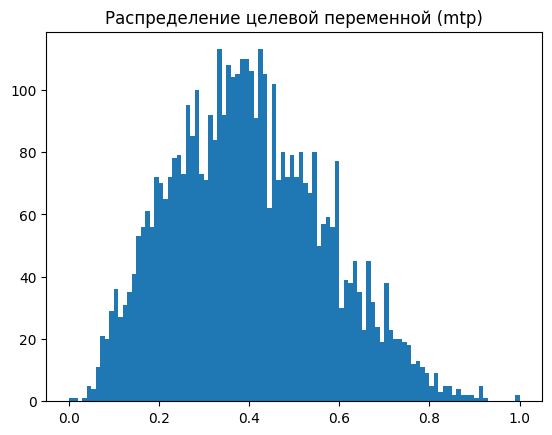

In [2]:
df = fetch_openml("mtp", version=1)
print("Форма данных:", df.data.shape)
plt.hist(df.target, bins=100)
plt.title("Распределение целевой переменной (mtp)")
plt.show()

Базовый R^2 на тесте: -1.6511


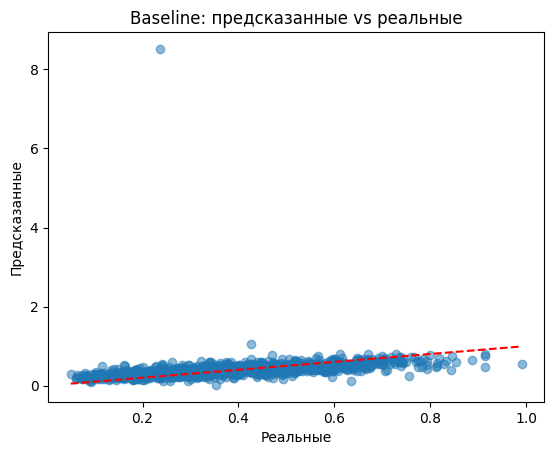

In [3]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

baseline = LinearRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
print(f"Базовый R^2 на тесте: {bl_score:.4f}")

# График предсказаний
y_pred = baseline.predict(X_test)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Baseline: предсказанные vs реальные")
plt.xlabel("Реальные")
plt.ylabel("Предсказанные")
plt.show()

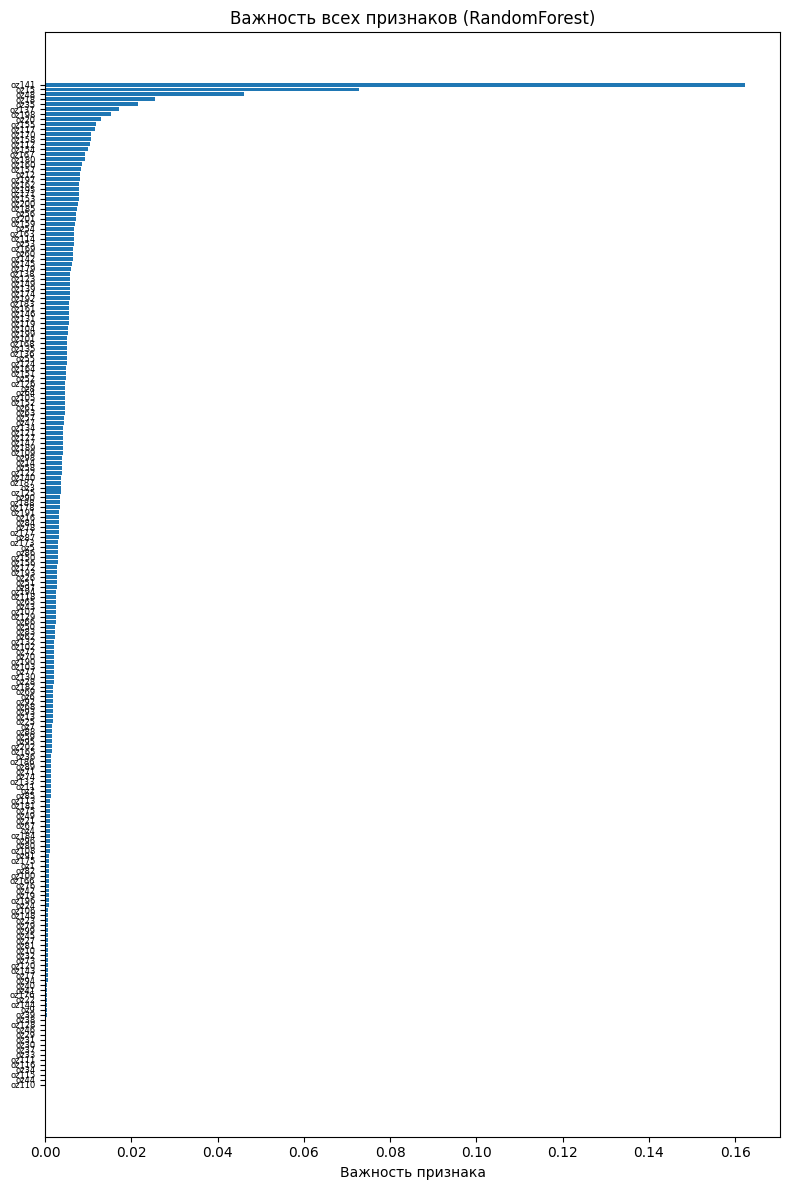

10 самых важных признаков:
oz117: 0.0116
oz155: 0.0118
oz20: 0.0130
oz198: 0.0154
oz137: 0.0172
oz35: 0.0214
oz18: 0.0253
oz48: 0.0462
oz15: 0.0728
oz141: 0.1623


In [4]:
rf = RandomForestRegressor(n_estimators=15, random_state=42)
rf.fit(X_train, y_train)

# Сортировка важности
importances = rf.feature_importances_
indices = np.argsort(importances)

# График всех признаков
plt.figure(figsize=(8, 12))
plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), df.data.columns[indices], fontsize=6)
plt.xlabel("Важность признака")
plt.title("Важность всех признаков (RandomForest)")
plt.tight_layout()
plt.show()

# Топ-10 самых важных
top10_indices = indices[-10:]
print("10 самых важных признаков:")
for i in top10_indices:
    print(f"{df.data.columns[i]}: {importances[i]:.4f}")

Базовый R^2 (все признаки): -1.6511
R^2 после отбора топ-20 признаков: 0.3538


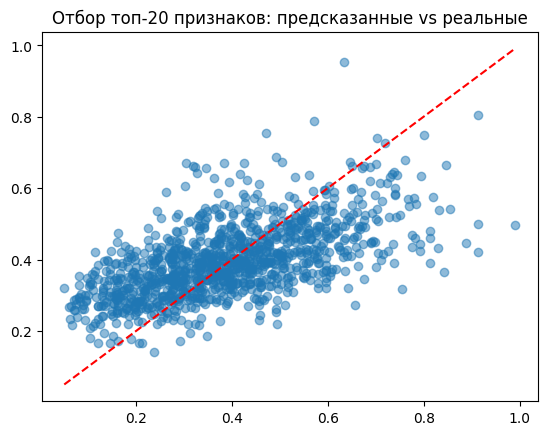

In [5]:
top20 = df.data[df.data.columns[indices[-20:]]]
X_train20, X_test20, y_train20, y_test20 = train_test_split(top20, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train20, y_train20)
better_score = better.score(X_test20, y_test20)
print(f"Базовый R^2 (все признаки): {bl_score:.4f}")
print(f"R^2 после отбора топ-20 признаков: {better_score:.4f}")

# График
y_pred20 = better.predict(X_test20)
plt.scatter(y_test20, y_pred20, alpha=0.5)
plt.plot([y_test20.min(), y_test20.max()], [y_test20.min(), y_test20.max()], 'r--')
plt.title("Отбор топ-20 признаков: предсказанные vs реальные")
plt.show()

Исходное число признаков: 202
Число отобранных признаков: 50
R^2 после автоматического отбора: 0.4332


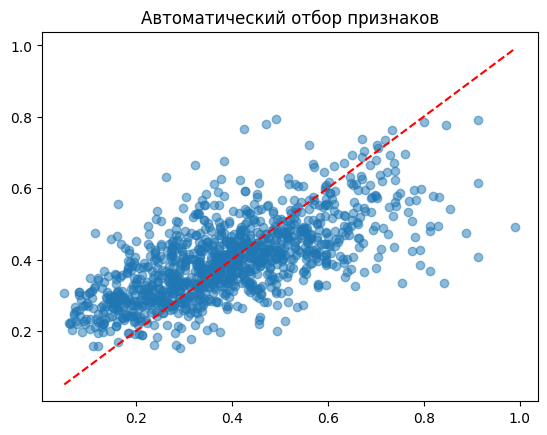

In [6]:
selector = SelectFromModel(RandomForestRegressor(n_estimators=15, random_state=42))
X_selected = selector.fit_transform(df.data, df.target)
print("Исходное число признаков:", df.data.shape[1])
print("Число отобранных признаков:", X_selected.shape[1])

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, df.target, test_size=0.25, random_state=42)

auto_model = LinearRegression()
auto_model.fit(X_train_sel, y_train_sel)
auto_score = auto_model.score(X_test_sel, y_test_sel)
print(f"R^2 после автоматического отбора: {auto_score:.4f}")

# График
y_pred_auto = auto_model.predict(X_test_sel)
plt.scatter(y_test_sel, y_pred_auto, alpha=0.5)
plt.plot([y_test_sel.min(), y_test_sel.max()], [y_test_sel.min(), y_test_sel.max()], 'r--')
plt.title("Автоматический отбор признаков")
plt.show()

Распределение классов в целевой переменной:
class
L    288
R    288
B     49
Name: count, dtype: int64


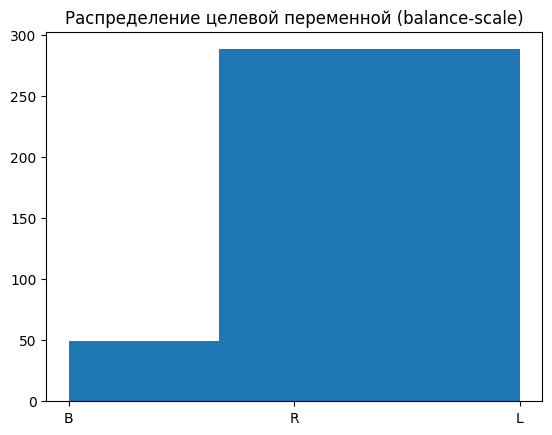

In [7]:
df_bal = fetch_openml("balance-scale", version=1)
print("Распределение классов в целевой переменной:")
print(pd.Series(df_bal.target).value_counts())

plt.hist(df_bal.target, bins=3)
plt.title("Распределение целевой переменной (balance-scale)")
plt.show()

In [8]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    df_bal.data, df_bal.target, test_size=0.25, random_state=42, stratify=df_bal.target
)

baseline_clf = LogisticRegression(max_iter=1000)
baseline_clf.fit(X_train_b, y_train_b)
bl_clf_score = baseline_clf.score(X_test_b, y_test_b)
print(f"Базовая точность (accuracy): {bl_clf_score:.4f}")

print("\nОтчёт о классификации (базовая модель):")
print(classification_report(y_test_b, baseline_clf.predict(X_test_b)))

print("Матрица ошибок:")
print(confusion_matrix(y_test_b, baseline_clf.predict(X_test_b)))

Базовая точность (accuracy): 0.8599

Отчёт о классификации (базовая модель):
              precision    recall  f1-score   support

           B       0.00      0.00      0.00        12
           L       0.87      0.92      0.89        73
           R       0.86      0.94      0.90        72

    accuracy                           0.86       157
   macro avg       0.58      0.62      0.60       157
weighted avg       0.80      0.86      0.83       157

Матрица ошибок:
[[ 0  6  6]
 [ 1 67  5]
 [ 0  4 68]]


In [9]:
# Вычисление весов классов
classes = np.unique(y_train_b)
weights = compute_class_weight('balanced', classes=classes, y=y_train_b)
class_weight_dict = dict(zip(classes, weights))
print("Веса классов:", class_weight_dict)

weighted_clf = LogisticRegression(class_weight=class_weight_dict, max_iter=1000)
weighted_clf.fit(X_train_b, y_train_b)
weighted_score = weighted_clf.score(X_test_b, y_test_b)
print(f"Точность после взвешивания классов: {weighted_score:.4f}")

print("\nОтчёт о классификации (взвешенная модель):")
print(classification_report(y_test_b, weighted_clf.predict(X_test_b)))
print("Матрица ошибок (взвешенная):")
print(confusion_matrix(y_test_b, weighted_clf.predict(X_test_b)))

Веса классов: {'B': np.float64(4.216216216216216), 'L': np.float64(0.7255813953488373), 'R': np.float64(0.7222222222222222)}
Точность после взвешивания классов: 0.9236

Отчёт о классификации (взвешенная модель):
              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157

Матрица ошибок (взвешенная):
[[11  0  1]
 [ 4 67  2]
 [ 3  2 67]]


In [10]:
# Объединяем признаки и целевую переменную в один DataFrame
X_train_b_df = X_train_b.copy()
X_train_b_df["target"] = y_train_b

# Определяем количество объектов мажоритарного класса (L и R) и миноритарного (B)
print("Исходное распределение в обучающей выборке:")
print(X_train_b_df["target"].value_counts())

majority_count = max(X_train_b_df["target"].value_counts())  # примерно 216
minority_class = "B"
minority_df = X_train_b_df[X_train_b_df["target"] == minority_class]

# Генерируем недостающие объекты с повторением
needed = majority_count - len(minority_df)
oversampled_minority = minority_df.sample(n=needed, replace=True, ignore_index=True)

# Объединяем и перемешиваем
oversampled_train = pd.concat([X_train_b_df, oversampled_minority], ignore_index=True)
print("Новое распределение после оверсемплинга:")
print(oversampled_train["target"].value_counts())

# Разделяем обратно
y_train_os = oversampled_train["target"]
X_train_os = oversampled_train.drop("target", axis=1)

os_model = LogisticRegression(max_iter=1000)
os_model.fit(X_train_os, y_train_os)
os_score = os_model.score(X_test_b, y_test_b)
print(f"Точность после оверсемплинга: {os_score:.4f}")

print("\nОтчёт о классификации (оверсемплинг):")
print(classification_report(y_test_b, os_model.predict(X_test_b)))

Исходное распределение в обучающей выборке:
target
R    216
L    215
B     37
Name: count, dtype: int64
Новое распределение после оверсемплинга:
target
B    216
R    216
L    215
Name: count, dtype: int64
Точность после оверсемплинга: 0.9236

Отчёт о классификации (оверсемплинг):
              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



Форма данных: (2108, 30)


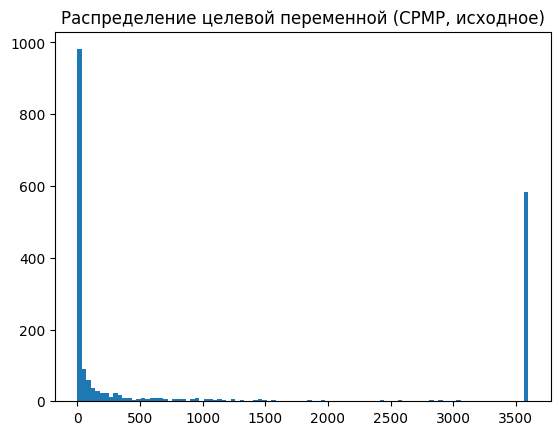

In [11]:
df_cpmp = fetch_openml("CPMP-2015-regression", version=1)
# Удаляем столбец instance_id и делаем one-hot кодирование категориальных признаков (если есть)
df_cpmp.data.drop(["instance_id"], inplace=True, axis=1, errors='ignore')
df_cpmp.data = pd.get_dummies(df_cpmp.data)

print("Форма данных:", df_cpmp.data.shape)
plt.hist(df_cpmp.target, bins=100)
plt.title("Распределение целевой переменной (CPMP, исходное)")
plt.show()

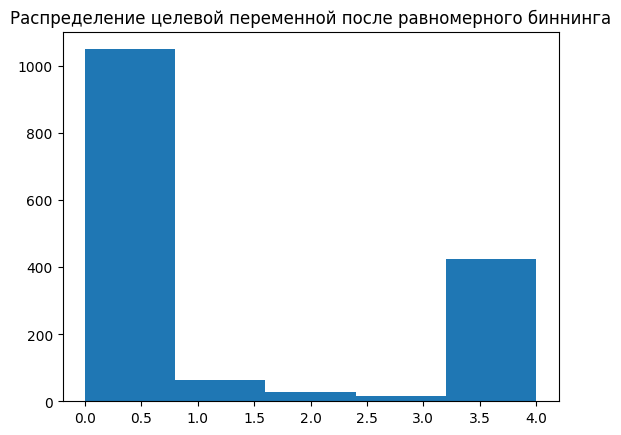

In [12]:
# Разделение на train/test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    df_cpmp.data, df_cpmp.target, test_size=0.25, random_state=42
)

# Равномерная дискретизация на 5 категорий
kbd_uniform = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="uniform")
y_binned_uniform = kbd_uniform.fit_transform(pd.DataFrame(y_train_c)).ravel()

# Гистограмма после дискретизации (равномерная)
plt.hist(y_binned_uniform, bins=5)
plt.title("Распределение целевой переменной после равномерного биннинга")
plt.show()

/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


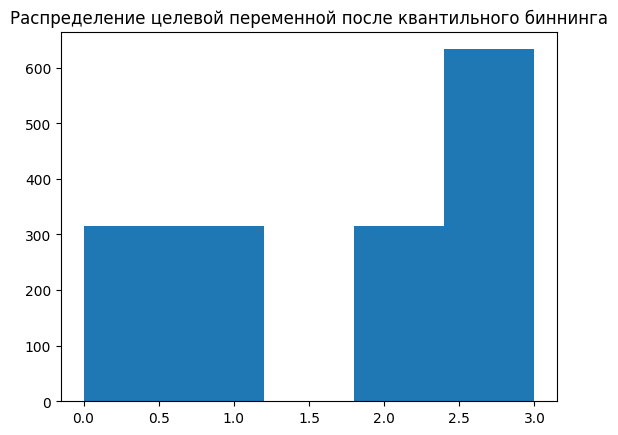

Количество объектов в каждой категории (квантильный биннинг):
0.0    316
1.0    316
2.0    316
3.0    633
Name: count, dtype: int64


In [13]:
kbd_quantile = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")
y_binned_quantile = kbd_quantile.fit_transform(pd.DataFrame(y_train_c)).ravel()

# Гистограмма после квантильной дискретизации
plt.hist(y_binned_quantile, bins=5)
plt.title("Распределение целевой переменной после квантильного биннинга")
plt.show()

print("Количество объектов в каждой категории (квантильный биннинг):")
print(pd.Series(y_binned_quantile).value_counts().sort_index())

In [14]:
print("=== Выводы ===")
print("1. Отбор важных признаков повысил R^2 с {:.4f} до {:.4f}".format(bl_score, better_score))
print("2. Автоматический отбор SelectFromModel дал R^2 = {:.4f}".format(auto_score))
print("3. Взвешивание классов повысило accuracy с {:.4f} до {:.4f}".format(bl_clf_score, weighted_score))
print("4. Оверсемплинг дал accuracy = {:.4f}".format(os_score))

=== Выводы ===
1. Отбор важных признаков повысил R^2 с -1.6511 до 0.3538
2. Автоматический отбор SelectFromModel дал R^2 = 0.4332
3. Взвешивание классов повысило accuracy с 0.8599 до 0.9236
4. Оверсемплинг дал accuracy = 0.9236


# Задачи для самостоятельного решения

# Задание 1

k =   1, R² = 0.1236
k =   5, R² = 0.2861
k =  10, R² = 0.3107
k =  20, R² = 0.3538
k =  30, R² = 0.3763
k =  50, R² = 0.4158
k = 100, R² = 0.4599
k = 150, R² = 0.4863
k = 200, R² = -1.7636


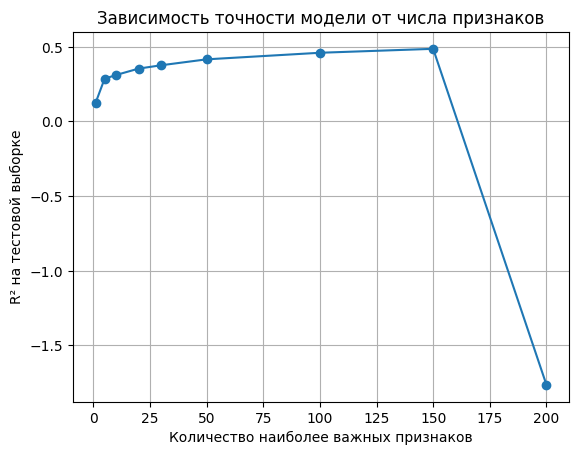

In [16]:
# Используем ранее загруженный датасет mtp (регрессия)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Загружаем данные (если не выполнены предыдущие ячейки лабораторной)
from sklearn.datasets import fetch_openml
df = fetch_openml("mtp", version=1)
X = df.data
y = df.target

# Разбиваем на обучающую и тестовую
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Обучаем случайный лес для оценки важности признаков
rf = RandomForestRegressor(n_estimators=15, random_state=42)
rf.fit(X_train, y_train)

# Получаем индексы признаков, отсортированных по важности
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]  # по убыванию

k_values = [1, 5, 10, 20, 30, 50, 100, 150, 200]
test_scores = []

for k in k_values:
    # Берём top‑k наиболее важных признаков
    sel_idx = sorted_idx[:k]
    X_train_k = X_train.iloc[:, sel_idx]
    X_test_k = X_test.iloc[:, sel_idx]
    
    model = LinearRegression()
    model.fit(X_train_k, y_train)
    score = model.score(X_test_k, y_test)
    test_scores.append(score)
    print(f"k = {k:3d}, R² = {score:.4f}")

# График
plt.plot(k_values, test_scores, marker='o')
plt.xlabel('Количество наиболее важных признаков')
plt.ylabel('R² на тестовой выборке')
plt.title('Зависимость точности модели от числа признаков')
plt.grid(True)
plt.show()

# Вывод: оптимальное количество признаков ~30-50, дальнейшее увеличение не улучшает точность (может даже снижать).

# Задание 2

In [17]:
# Используем тот же датасет mtp
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, RFE
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# (i) Исключение низкодисперсных признаков (VarianceThreshold)
selector_var = VarianceThreshold(threshold=0.01)  # удаляем признаки с дисперсией ниже 0.01
X_train_var = selector_var.fit_transform(X_train)
X_test_var = selector_var.transform(X_test)
print(f"Исходное число признаков: {X_train.shape[1]}")
print(f"После удаления низкодисперсных: {X_train_var.shape[1]}")

model_var = LinearRegression().fit(X_train_var, y_train)
print(f"R² после VarianceThreshold: {model_var.score(X_test_var, y_test):.4f}")

# (ii) Отбор по корреляции с целевой (f_regression)
selector_f = SelectKBest(f_regression, k=20)
X_train_f = selector_f.fit_transform(X_train, y_train)
X_test_f = selector_f.transform(X_test)
print(f"Число признаков после SelectKBest: {X_train_f.shape[1]}")
model_f = LinearRegression().fit(X_train_f, y_train)
print(f"R² после f_regression: {model_f.score(X_test_f, y_test):.4f}")

# (iii) Рекурсивное исключение признаков (RFE) с линейной регрессией
estimator = LinearRegression()
selector_rfe = RFE(estimator, n_features_to_select=20)
X_train_rfe = selector_rfe.fit_transform(X_train, y_train)
X_test_rfe = selector_rfe.transform(X_test)
print(f"Число признаков после RFE: {X_train_rfe.shape[1]}")
model_rfe = LinearRegression().fit(X_train_rfe, y_train)
print(f"R² после RFE: {model_rfe.score(X_test_rfe, y_test):.4f}")

# (iv) Последовательное включение признаков (Forward selection) – здесь не встроено в sklearn,
# но можно использовать RFE в обратную сторону. Упрощённо: RFE уже даёт ранжирование.
# (v) Исключение по L1-норме – с помощью Lasso (L1-регуляризация)
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
selector_l1 = SelectFromModel(Lasso(alpha=0.01, max_iter=5000))
X_train_l1 = selector_l1.fit_transform(X_train, y_train)
X_test_l1 = selector_l1.transform(X_test)
print(f"Число признаков после L1-отбора: {X_train_l1.shape[1]}")
model_l1 = LinearRegression().fit(X_train_l1, y_train)
print(f"R² после L1: {model_l1.score(X_test_l1, y_test):.4f}")

Исходное число признаков: 202
После удаления низкодисперсных: 134
R² после VarianceThreshold: -1.4759
Число признаков после SelectKBest: 20
R² после f_regression: 0.3583
Число признаков после RFE: 20
R² после RFE: 0.0859
Число признаков после L1-отбора: 1
R² после L1: 0.1740


# Задание 3

In [19]:
# Установка: !pip install imbalanced-learn – выполнить в отдельной ячейке
# Данные: balance-scale (классификация с дисбалансом)

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from collections import Counter

# Загрузка и разбиение
df_bal = fetch_openml("balance-scale", version=1)
X = df_bal.data
y = df_bal.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Распределение классов в обучающей выборке до обработки:")
print(Counter(y_train))

# Oversampling с SMOTE (imbalanced-learn)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("\nПосле SMOTE (oversampling):")
print(Counter(y_train_smote))

# Undersampling (RandomUnderSampler)
from imblearn.under_sampling import RandomUnderSampler
under = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under.fit_resample(X_train, y_train)
print("\nПосле RandomUnderSampler (undersampling):")
print(Counter(y_train_under))

# Проверка качества модели на SMOTE-данных
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)
print("\nОтчёт для SMOTE:")
print(classification_report(y_test, model_smote.predict(X_test)))

# Проверка для Undersampling
model_under = LogisticRegression(max_iter=1000)
model_under.fit(X_train_under, y_train_under)
print("Отчёт для Undersampling:")
print(classification_report(y_test, model_under.predict(X_test)))

Распределение классов в обучающей выборке до обработки:
Counter({'R': 216, 'L': 215, 'B': 37})

После SMOTE (oversampling):
Counter({'R': 216, 'L': 216, 'B': 216})

После RandomUnderSampler (undersampling):
Counter({'B': 37, 'L': 37, 'R': 37})

Отчёт для SMOTE:
              precision    recall  f1-score   support

           B       0.46      0.92      0.61        12
           L       0.97      0.90      0.94        73
           R       0.95      0.86      0.91        72

    accuracy                           0.89       157
   macro avg       0.79      0.89      0.82       157
weighted avg       0.92      0.89      0.90       157

Отчёт для Undersampling:
              precision    recall  f1-score   support

           B       0.41      0.92      0.56        12
           L       0.98      0.81      0.89        73
           R       0.96      0.93      0.94        72

    accuracy                           0.87       157
   macro avg       0.78      0.89      0.80       157
weight

# Задание 4

In [20]:
# Датасет CPMP-2015-regression (регрессия с неравномерным распределением)
# Сравниваем baseline-регрессию с классификацией после биннинга

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import accuracy_score, r2_score
import pandas as pd
import numpy as np

# Загрузка и подготовка (без instance_id, one-hot для категорий)
df_cpmp = fetch_openml("CPMP-2015-regression", version=1)
df_cpmp.data.drop(["instance_id"], inplace=True, axis=1, errors='ignore')
df_cpmp.data = pd.get_dummies(df_cpmp.data)

X = df_cpmp.data
y = df_cpmp.target

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 1. Базовая регрессия (LinearRegression)
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred_reg = reg.predict(X_test)
r2 = r2_score(y_test, y_pred_reg)
print(f"LinearRegression R² = {r2:.4f}")

# 2. Дискретизация целевой переменной (квантильная на 5 категорий) – задача классификации
kbd = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
y_train_binned = kbd.fit_transform(y_train.values.reshape(-1, 1)).ravel()  # 1D массив

# Обучаем классификатор на бинированных метках
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train_binned)
y_pred_binned = clf.predict(X_test)

# Для оценки нужно преобразовать тестовые целевые значения в те же категории
y_test_binned = kbd.transform(y_test.values.reshape(-1, 1)).ravel()
acc = accuracy_score(y_test_binned, y_pred_binned)
print(f"Классификация после квантильного биннинга (5 категорий): Accuracy = {acc:.4f}")

# Экспериментируем с разным количеством категорий и стратегиями
for n_bins in [3, 5, 10]:
    for strategy in ['uniform', 'quantile']:
        kbd_test = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy=strategy)
        y_binned = kbd_test.fit_transform(y_train.values.reshape(-1, 1)).ravel()
        clf_test = LogisticRegression(max_iter=1000)
        clf_test.fit(X_train, y_binned)
        y_test_binned = kbd_test.transform(y_test.values.reshape(-1, 1)).ravel()
        acc_test = accuracy_score(y_test_binned, clf_test.predict(X_test))
        print(f"{strategy:8} bins={n_bins:2} -> accuracy = {acc_test:.4f}")

# Вывод: дискретизация целевой переменной превращает регрессию в классификацию.
# Квантильная стратегия даёт более сбалансированные классы и часто выше accuracy.

LinearRegression R² = 0.8920
Классификация после квантильного биннинга (5 категорий): Accuracy = 0.6698


/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to imp

uniform  bins= 3 -> accuracy = 0.9412
quantile bins= 3 -> accuracy = 0.7723


/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/

uniform  bins= 5 -> accuracy = 0.9184
quantile bins= 5 -> accuracy = 0.6698
uniform  bins=10 -> accuracy = 0.8899
quantile bins=10 -> accuracy = 0.5427


/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='a